In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import plot_tree

In [2]:
PATH = "asteroid.csv"

In [3]:
df = pd.read_csv(PATH)

C:\Users\ponts\AppData\Local\Temp\ipykernel_30384\3476328945.py:1: DtypeWarning: Columns (0: pdes, 1: name, 2: prefix) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PATH)


In [4]:
print(df.shape)

(958524, 45)


In [5]:
display(df['equinox'].head())

0    J2000
1    J2000
2    J2000
3    J2000
4    J2000
Name: equinox, dtype: str

- Drop columns which cannot be quantified

In [6]:
columns = df.columns

def get_unique_values(df, columns):

    for col in columns:
        unique_values = df[col].unique()
        print(f"Unique values in column '{col}': {unique_values.size}")

get_unique_values(df, columns)

Unique values in column 'id': 958524
Unique values in column 'spkid': 958524
Unique values in column 'full_name': 958524
Unique values in column 'pdes': 958524
Unique values in column 'name': 22065
Unique values in column 'prefix': 2
Unique values in column 'neo': 3
Unique values in column 'pha': 3
Unique values in column 'H': 9490
Unique values in column 'diameter': 16592
Unique values in column 'albedo': 1058
Unique values in column 'diameter_sigma': 3055
Unique values in column 'orbit_id': 4690
Unique values in column 'epoch': 5246
Unique values in column 'epoch_mjd': 5246
Unique values in column 'epoch_cal': 5246
Unique values in column 'equinox': 1
Unique values in column 'e': 958444
Unique values in column 'a': 958509
Unique values in column 'q': 958509
Unique values in column 'i': 958414
Unique values in column 'om': 958518
Unique values in column 'w': 958519
Unique values in column 'ma': 958520
Unique values in column 'ad': 958506
Unique values in column 'n': 958514
Unique valu

In [7]:
### Drop string based columns that cannot be quantitatively analyzed

# Selected columns are selected based on their unique value count and their relevance to the problem at hand.
columns_to_drop = [
    "spkid",
    "full_name",
    "pdes",
    "name",
    "prefix",
    "equinox",
    "diameter_sigma",
    "epoch_mjd",
    "epoch_cal",
    "orbit_id"
    "tp_cal",
    "per_y",
    "moid_ld"
]

cols_to_drop = [c for c in columns_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)

In [8]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
id                0
neo               4
pha           19921
H              6263
diameter     822315
albedo       823421
orbit_id          0
epoch             0
e                 0
a                 0
q                 0
i                 0
om                0
w                 0
ma                1
ad                4
n                 0
tp                0
tp_cal            0
per               4
moid          19921
sigma_e       19922
sigma_a       19922
sigma_q       19922
sigma_i       19922
sigma_om      19922
sigma_w       19922
sigma_ma      19922
sigma_ad      19926
sigma_n       19922
sigma_tp      19922
sigma_per     19926
class             0
rms               2
dtype: int64


In [9]:
print("Duplicate rows in the dataset:", df.duplicated().sum())

Duplicate rows in the dataset: 0


- Dropping rows by searching for null rows removes every entry

- Since my main focus on the diameter of Asteroids, missing asteroid data will only hinder my research
    - So i will remove rows with missing diameters

In [10]:
# df = df.dropna(subset=['diameter'])
#Remove rows with null values in every column that is left.
columns = df.columns

for col in columns:
    df = df.dropna(subset=[col])

In [11]:
print("Dataset shape after removing rows with NaN values:", df.isnull().sum())

Dataset shape after removing rows with NaN values: id           0
neo          0
pha          0
H            0
diameter     0
albedo       0
orbit_id     0
epoch        0
e            0
a            0
q            0
i            0
om           0
w            0
ma           0
ad           0
n            0
tp           0
tp_cal       0
per          0
moid         0
sigma_e      0
sigma_a      0
sigma_q      0
sigma_i      0
sigma_om     0
sigma_w      0
sigma_ma     0
sigma_ad     0
sigma_n      0
sigma_tp     0
sigma_per    0
class        0
rms          0
dtype: int64


In [12]:
print(df.shape)

(131237, 34)


- Dataframe is now free of Null entries.

### 2. Categorical Encoding

In [13]:
### Set ID as index

df = df.set_index('id')

### Label encoding vs One-Hot Encoding

1. Label encoding creates an order to the categories

2. One-Hot Encoder simply categorises the data with no ranking/order

In [14]:
### Testing which columns to encode

# Check which columns are categorical and need encoding
columns_to_encode = ['neo', 'pha', 'class']

In [15]:
def encode_categorical_columns(df, columns):
    encoded_df = df.copy()
    binary_cols = []
    one_hot_cols = []

    for col in columns:
        if col not in encoded_df.columns:
            continue

        n_unique = encoded_df[col].nunique(dropna=True)

        if n_unique == 2:
            le = LabelEncoder()
            encoded_df[col] = le.fit_transform(encoded_df[col])
            binary_cols.append(col)
        elif n_unique > 2:
            one_hot_cols.append(col)

    if one_hot_cols:
        encoded_df = pd.get_dummies(encoded_df, columns=one_hot_cols, drop_first=True)

    return encoded_df, binary_cols, one_hot_cols

encoded_df, binary_cols, one_hot_cols = encode_categorical_columns(df, columns_to_encode)
print("Label-encoded columns:", binary_cols)
print("One-hot encoded columns:", one_hot_cols)
encoded_df.head()

Label-encoded columns: ['neo', 'pha']
One-hot encoded columns: ['class']


,neo,pha,H,diameter,albedo,orbit_id,epoch,e,a,q,...,class_APO,class_AST,class_ATE,class_CEN,class_IMB,class_MBA,class_MCA,class_OMB,class_TJN,class_TNO
id,,,,,,,,,,,,,,,,,,,,,
a0000001,0,0,3.40,939.400,0.0900,JPL 47,2458600.5,0.076009,2.769165,2.558684,...,False,False,False,False,False,True,False,False,False,False
a0000002,0,0,4.20,545.000,0.1010,JPL 37,2459000.5,0.229972,2.773841,2.135935,...,False,False,False,False,False,True,False,False,False,False
a0000003,0,0,5.33,246.596,0.2140,JPL 112,2459000.5,0.256936,2.668285,1.982706,...,False,False,False,False,False,True,False,False,False,False
a0000004,0,0,3.00,525.400,0.4228,JPL 35,2458600.5,0.088721,2.361418,2.151909,...,False,False,False,False,False,True,False,False,False,False
a0000005,0,0,6.90,106.699,0.2740,JPL 114,2459000.5,0.190913,2.574037,2.082619,...,False,False,False,False,False,True,False,False,False,False


### 3. Splitting the data

-  Splitting the dataset into data and test sets

In [16]:
x = encoded_df.drop(columns=['diameter', 'orbit_id'])
y = encoded_df['diameter']

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42, test_size=0.3)

In [17]:
print("\nTraining set shape:", x_train.shape)
print("Test set shape:", x_test.shape)


Training set shape: (91865, 40)
Test set shape: (39372, 40)


In [18]:
### Scale the data

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [19]:
# Convert back to DataFrame so feature names stay available
X_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns, index=x_train.index)
X_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns, index=x_test.index)

### 4. Modelling

#### Note

- We are trying to predict continuous data right

- **DecisionTreeClassifiers** are used to classify data into "Spam" or "Not Spam".

- **DecsionTreeRegressors** are use to predict continuous data.

In [20]:
# Train initial Decision Tree Regressor

regressor = DecisionTreeRegressor(max_depth=12, random_state=42)
regressor.fit(x_train_scaled, y_train)
y_pred = regressor.predict(x_test_scaled)

### 5. Feature Selection

In [21]:
# Get feature importances
importances = pd.Series(regressor.feature_importances_, index=x_train.columns)
importances = importances.sort_values(ascending=False)

print("\nTop feature importances:")
print(importances.head(10))

# Select features with importance greater than a threshold
threshold = 0.005  # Adjust as needed
selected_features = x.columns[importances > threshold]

# Use only the selected features
X_train_selected = x_train[selected_features]
X_test_selected = x_test[selected_features]


Top feature importances:
H          0.884205
albedo     0.088482
per        0.008144
n          0.006198
om         0.004540
i          0.001017
a          0.001010
sigma_i    0.000887
rms        0.000878
q          0.000829
dtype: float64


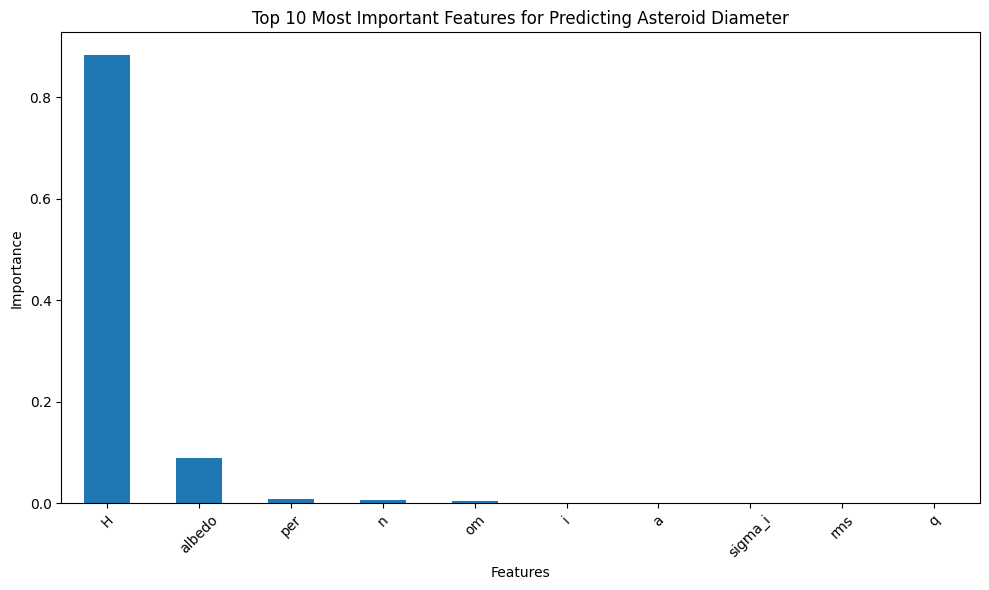

In [22]:
### Plot Selected Features

plt.figure(figsize=(10, 6))
importances.head(10).plot(kind="bar")
plt.title("Top 10 Most Important Features for Predicting Asteroid Diameter")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5. Modelling using selected features

In [23]:
# Train a new model using the selected features
regressor_selected = DecisionTreeRegressor(max_depth=12, random_state=8)
regressor_selected.fit(X_train_selected, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",8
,"max_leaf

In [24]:
y_pred_all_features = regressor.predict(x_test_scaled)
mae_all = mean_absolute_error(y_test, y_pred_all_features)
rmse_all = np.sqrt(mean_squared_error(y_test, y_pred_all_features))
r2_all = r2_score(y_test, y_pred_all_features)
print(f"All features -> MAE: {mae_all:.4f}, RMSE: {rmse_all:.4f}, R^2: {r2_all:.4f}")

y_pred_selected_features = regressor_selected.predict(X_test_selected)
mae_selected = mean_absolute_error(y_test, y_pred_selected_features)
rmse_selected = np.sqrt(mean_squared_error(y_test, y_pred_selected_features))
r2_selected = r2_score(y_test, y_pred_selected_features)
print(f"Selected features -> MAE: {mae_selected:.4f}, RMSE: {rmse_selected:.4f}, R^2: {r2_selected:.4f}")

All features -> MAE: 0.5091, RMSE: 2.7064, R^2: 0.9291
Selected features -> MAE: 0.4841, RMSE: 2.4259, R^2: 0.9431


### Plot decision Tree

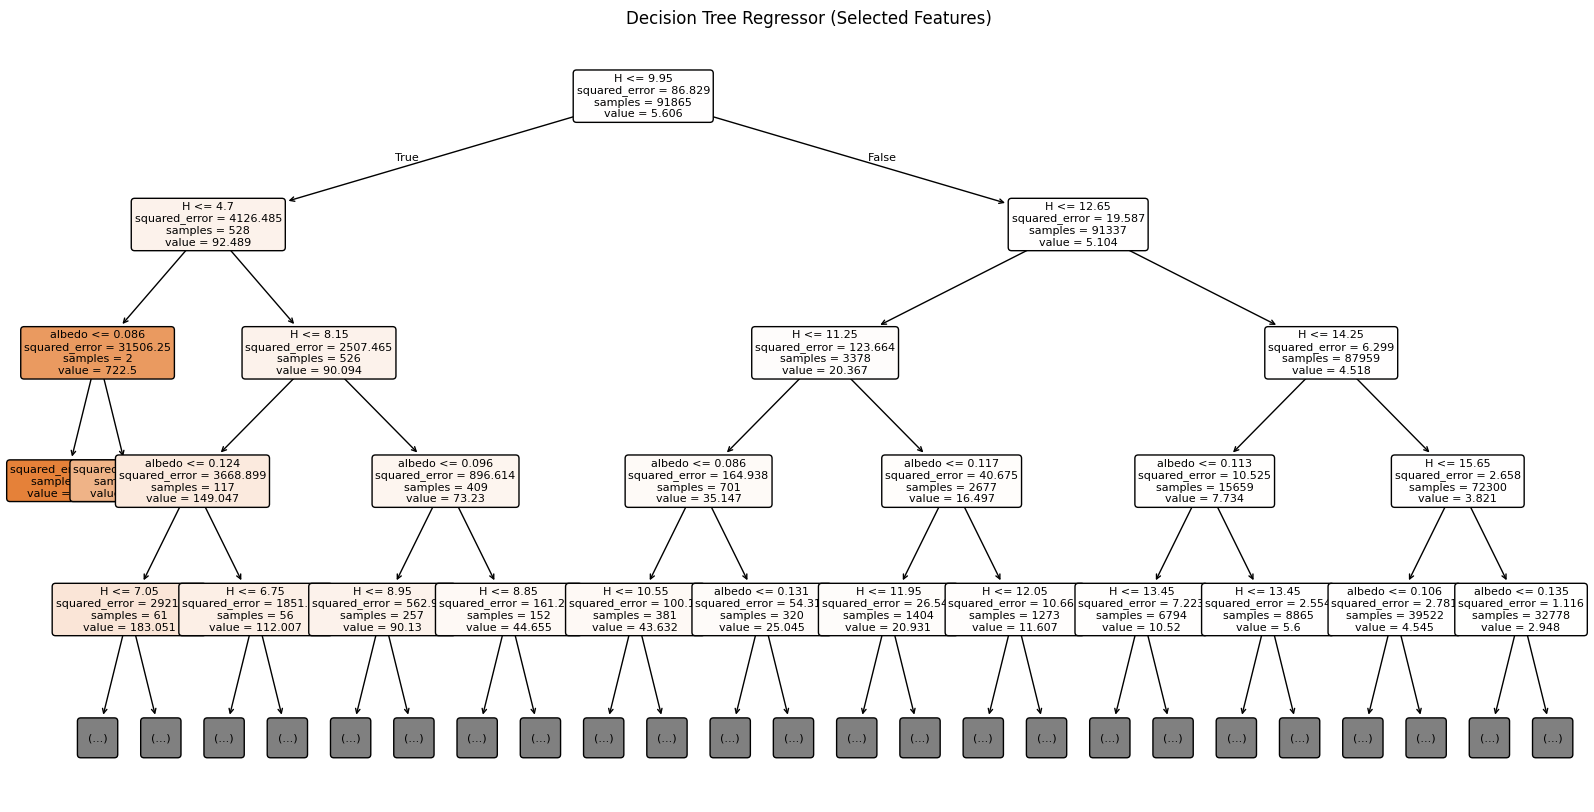

In [25]:
### Plot decision tree

plt.figure(figsize=(20, 10))
plot_tree(
    regressor_selected,
    feature_names=selected_features,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4  # remove this line to show full tree
)
plt.title("Decision Tree Regressor (Selected Features)")
plt.show()